<a href="https://colab.research.google.com/github/kjahan/stable_diffusion_demo/blob/master/notebooks/Img2Img_Stable_Diffusion_with_Diffusers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image to Iamge Stable Diffusion model

Original video:

https://www.youtube.com/watch?v=Xur1JeRjjOI

In [2]:
!nvidia-smi

Sat Nov  5 23:19:30 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   44C    P8    11W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

The below line is required as Hugging Face Diffusers on PyPi is not fully updated with StableDiffusion Pipeline. Hence we are are downloading it directly from Github. 

In [3]:
! pip install https://github.com/huggingface/diffusers/archive/main.zip -qUU --force-reinstall


     - 748 kB 8.6 MB/s
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 15.7 MB 13.6 MB/s 
     |████████████████████████████████| 62 kB 1.4 MB/s 
     |████████████████████████████████| 3.2 MB 53.7 MB/s 
     |████████████████████████████████| 757 kB 64.8 MB/s 
     |████████████████████████████████| 163 kB 67.9 MB/s 
     |████████████████████████████████| 78 kB 5.9 MB/s 
     |████████████████████████████████| 40 kB 5.0 MB/s 
     |████████████████████████████████| 596 kB 63.0 MB/s 
     |████████████████████████████████| 98 kB 7.6 MB/s 
     |████████████████████████████████| 161 kB 72.3 MB/s 
     |████████████████████████████████| 140 kB 64.3 MB/s 
     |████████████████████████████████| 61 kB 96 kB/s 
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency c

In [4]:
!pip install -qq -U transformers ftfy
!pip install -qq "ipywidgets>=7,<8"

     |████████████████████████████████| 5.5 MB 16.5 MB/s 
     |████████████████████████████████| 53 kB 1.9 MB/s 
     |████████████████████████████████| 7.6 MB 59.4 MB/s 
     |████████████████████████████████| 1.6 MB 14.7 MB/s 


In [5]:
from huggingface_hub import notebook_login

notebook_login()

Login successful
Your token has been saved to /root/.huggingface/token


In [6]:
! pip install --ignore-installed Pillow==9.0.0


# this fixes the module 'PIL.Image' has no attribute 'Resampling' error


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 4.3 MB 14.0 MB/s 


In [2]:
from torch import autocast
import torch
import requests
from PIL import Image
from io import BytesIO

from diffusers import StableDiffusionImg2ImgPipeline


In [3]:
# load the pipeline
device = "cuda"
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    revision="fp16", 
    torch_dtype=torch.float16,
    use_auth_token=True
).to(device)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

In [4]:
# let's download an initial image
url = "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Flh6.googleusercontent.com%2Fproxy%2FQBZTSycU3BmNf_YnyU4vm7Ammqx-aKnQcXSr_mD5xn28buzYMdg4G4NZOoxF8-hhW-a_HenRvkeiOnwnRw4Ll0TYjcs9HehMcoFWWsCpqA5BKAQCOUeJ5yd2eXnIlcxd_F6n7dugodr4GuwtI7aNtIqETNci0EFPeyc6sgVUx4f_1wHb_RwEXRGTxbc3L5jqYbde-ArPVo4_HRuJPBhmq-hJ86M4%3Dw1200-h630-p-k-no-nu&f=1&nofb=1"

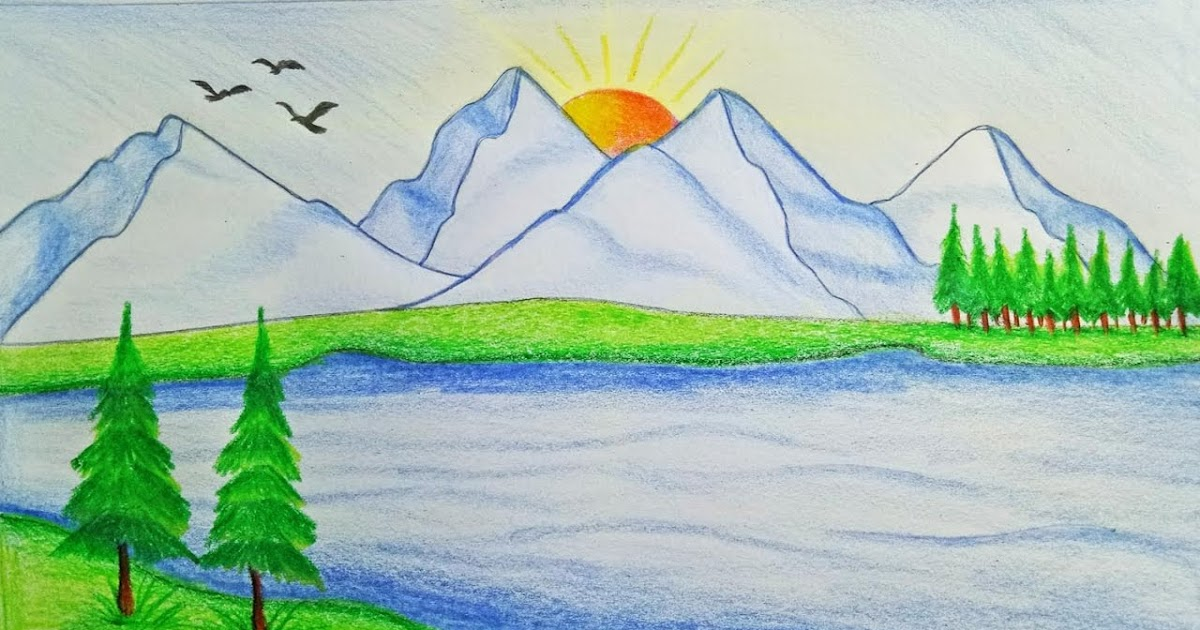

In [5]:
# Colab will ask you to "restart runtime" after installation. You should click "restart runtime"
# If you run into this error: AttributeError: module 'PIL.TiffTags' has no attribute 'IFD'
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image

In [6]:
init_image = init_image.resize((768, 512))
#init_image = preprocess(init_image)

In [7]:
prompt = "a fantasy land, trending on artstation by picasso"

In [8]:
with autocast("cuda"):
    images = pipe(prompt=prompt, init_image=init_image, strength=0.75, guidance_scale=7.5)


  0%|          | 0/38 [00:00<?, ?it/s]

In [9]:
images[0][0].save("nft_0.png")

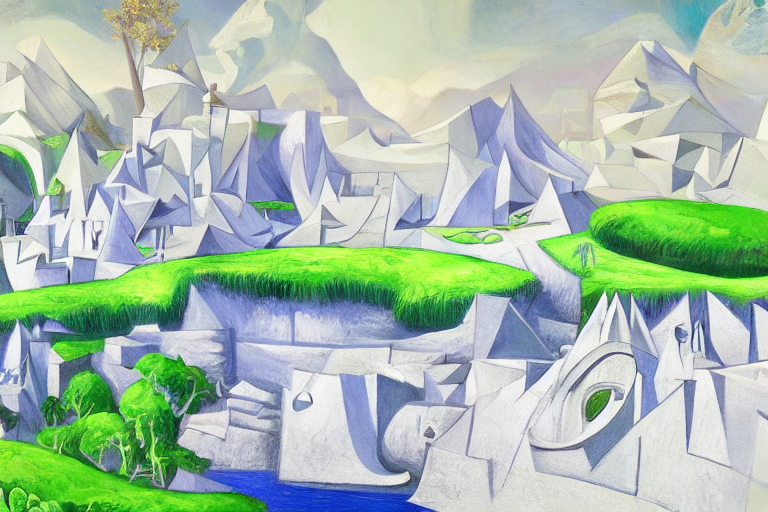

In [10]:
images[0][0]

In [11]:
# let's download an initial image
# Azuki https://www.azuki.com/gallery?id=8465
url = "https://ipfs.io/ipfs/QmYDvPAXtiJg7s8JdRBSLWdgSphQdac8j1YuQNNxcGE1hg/8465.png"

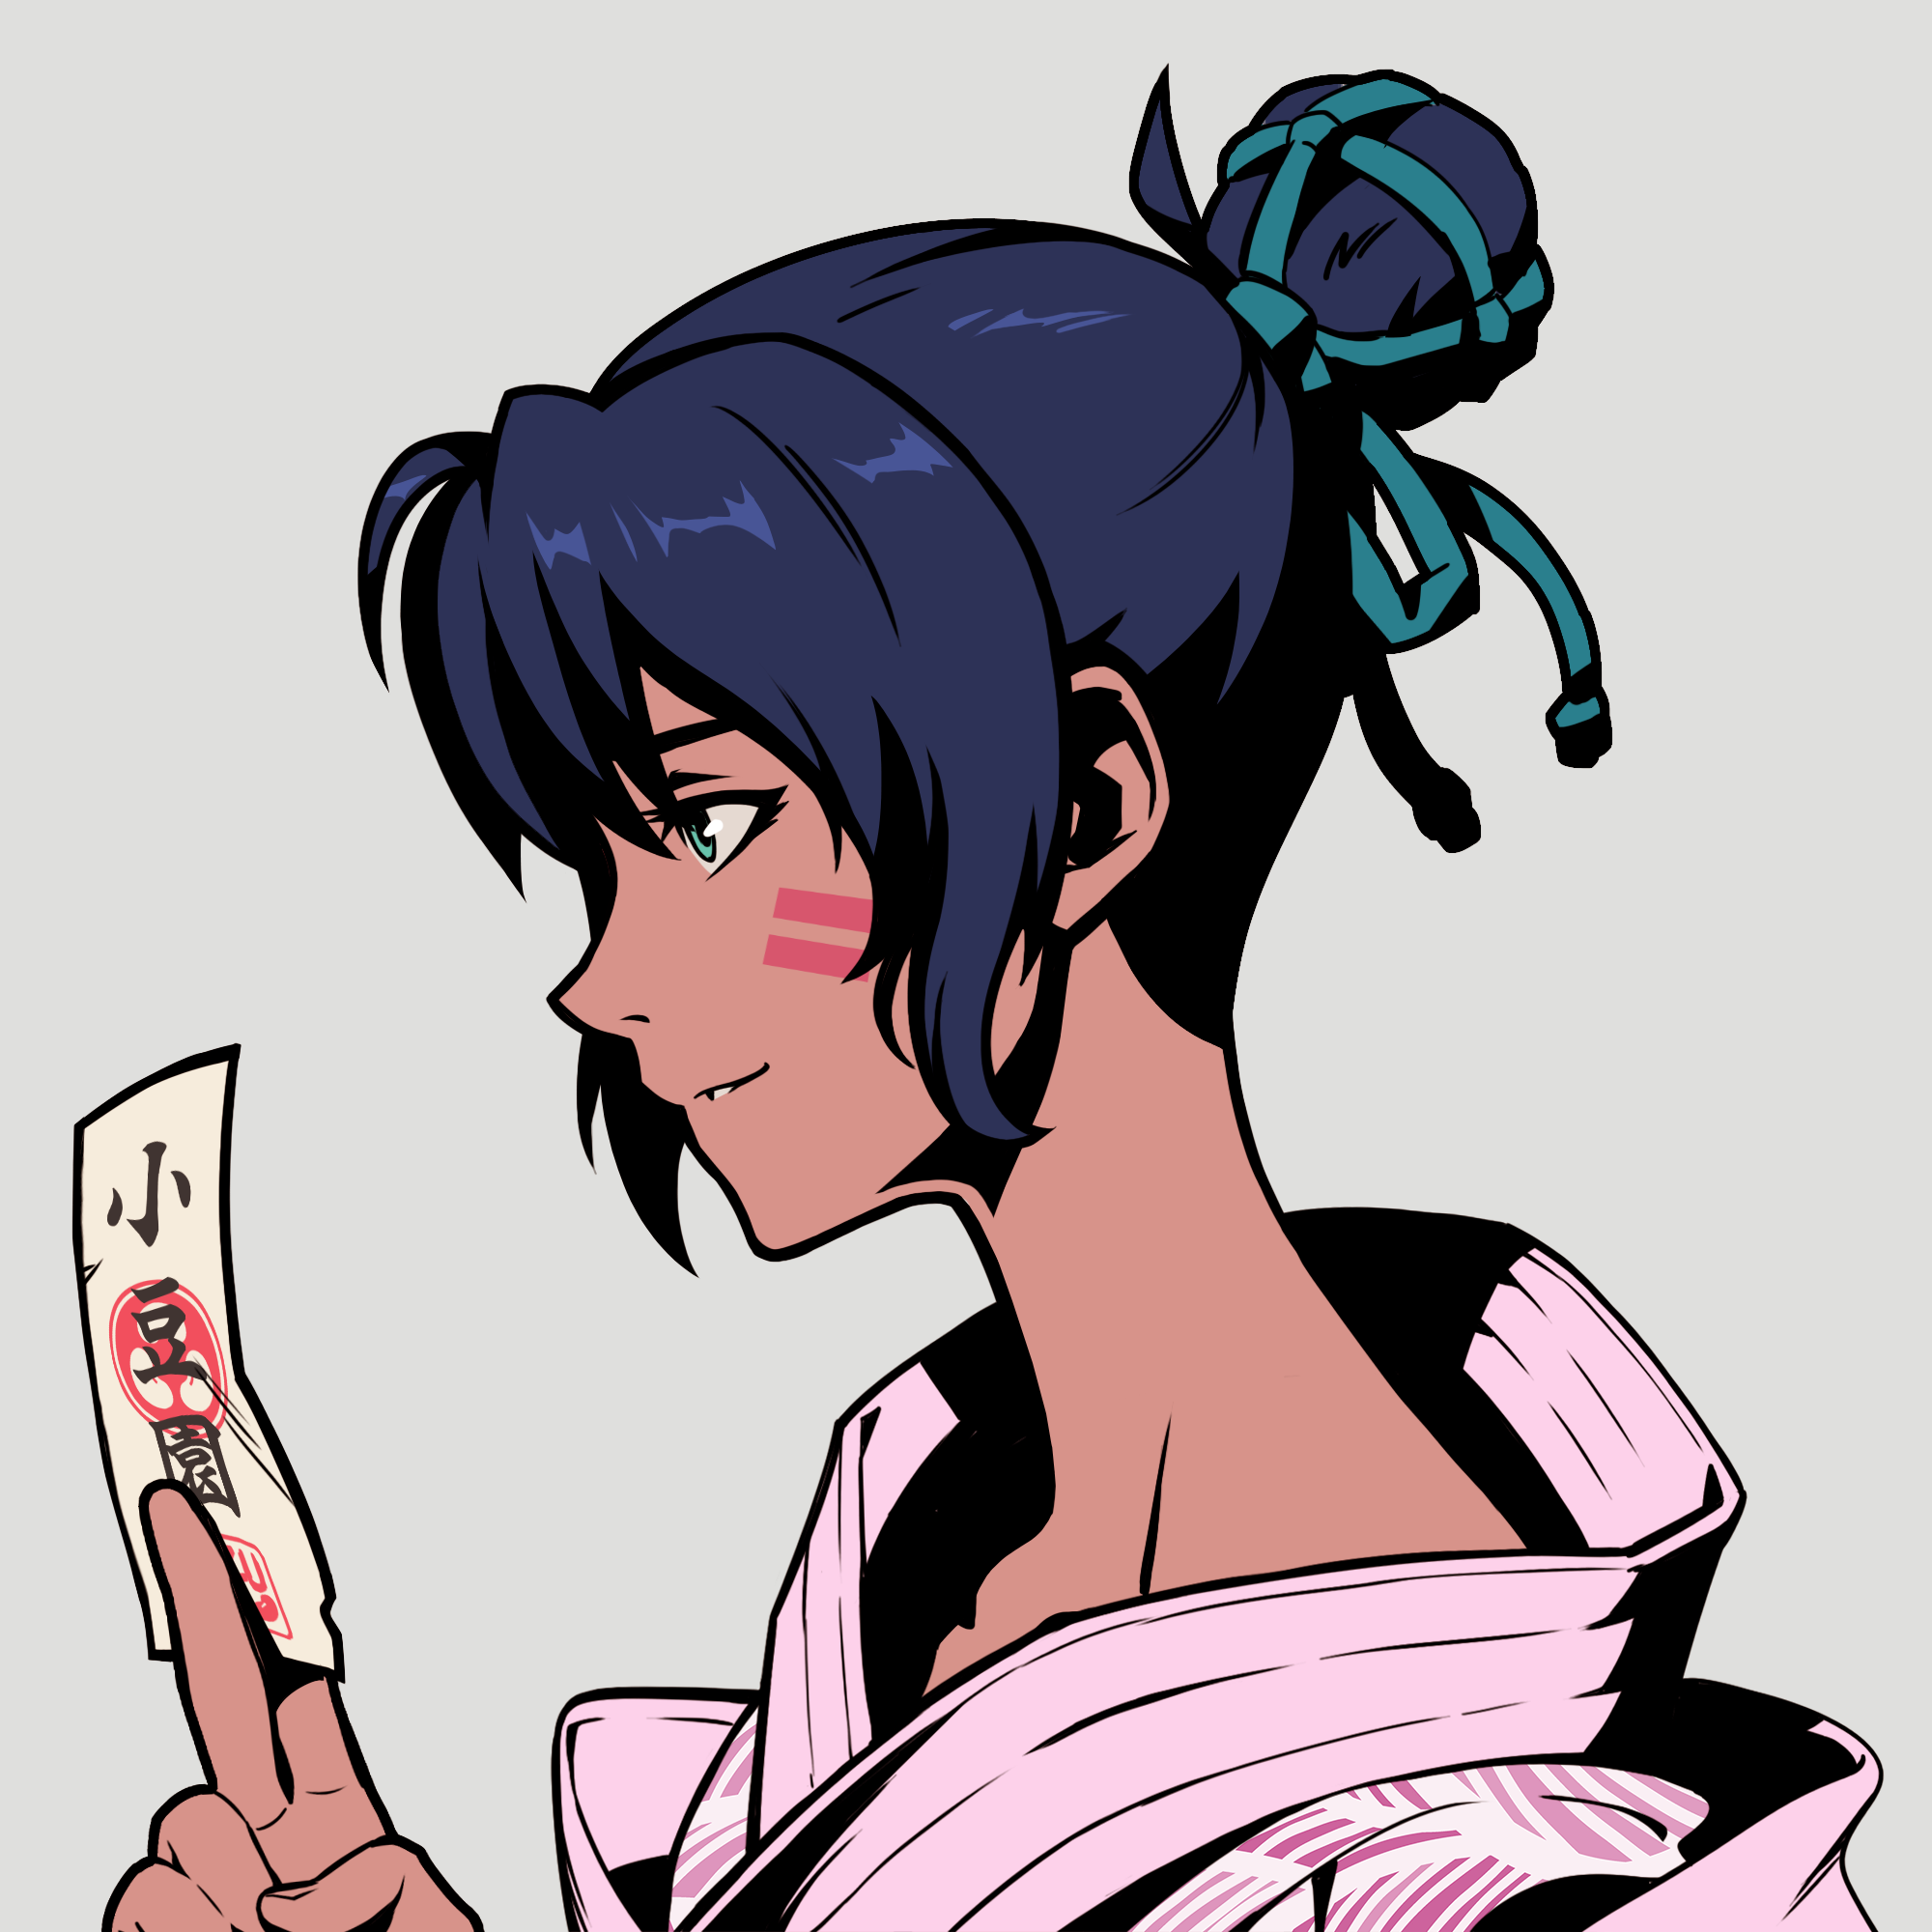

In [12]:
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image

In [13]:
init_image = init_image.resize((768, 512))
#init_image = preprocess(init_image)

In [18]:
# prompt = "a mystry woman with chopsticks"
prompt = "a fantasy woman with gun in tokyo"

In [19]:
with autocast("cuda"):
    images = pipe(prompt=prompt, init_image=init_image, strength=0.75, guidance_scale=7.5)

  0%|          | 0/38 [00:00<?, ?it/s]

In [20]:
images[0][0].save("nft_1.png")

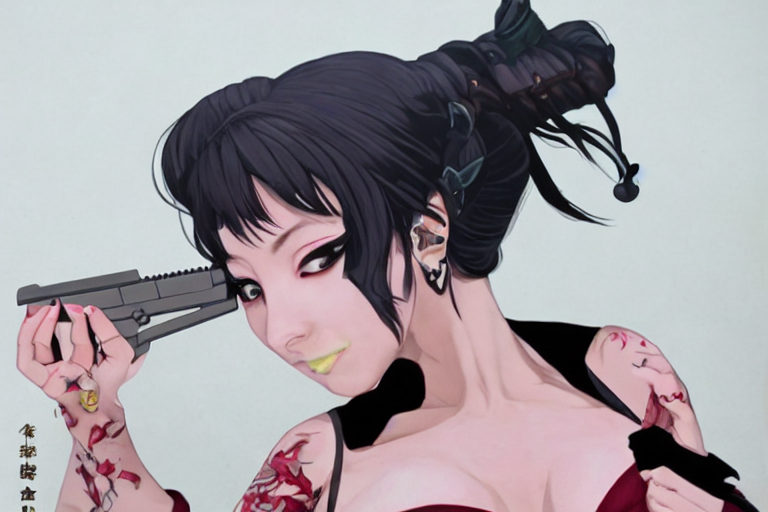

In [21]:
images[0][0]

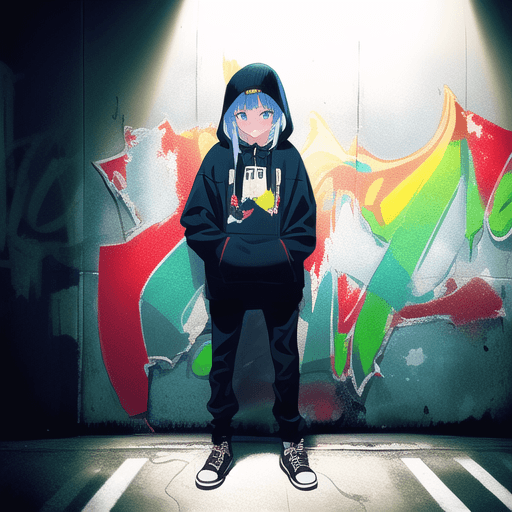

In [22]:
# https://opensea.io/assets/ethereum/0x495f947276749ce646f68ac8c248420045cb7b5e/1673696975965811788952744051363138032233820124664356965554422438805219835905
url = "https://i.seadn.io/gae/uDKN4XkkrnW58Fh6yyb8anFuE3YzPLLdIpjD5OhfhwwmWNlRsyRwxa3aHa__wpaV1L4Q0jl0_ozVEwejgTTF3LoBriJngh0WrszTDA?auto=format&w=1920"

response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image

In [23]:
init_image = init_image.resize((768, 512))
prompt = "a fantasy girl with gun in tokyo"

In [24]:
with autocast("cuda"):
    images = pipe(prompt=prompt, init_image=init_image, strength=0.75, guidance_scale=7.5)

  0%|          | 0/38 [00:00<?, ?it/s]

In [25]:
images[0][0].save("nft_2.png")

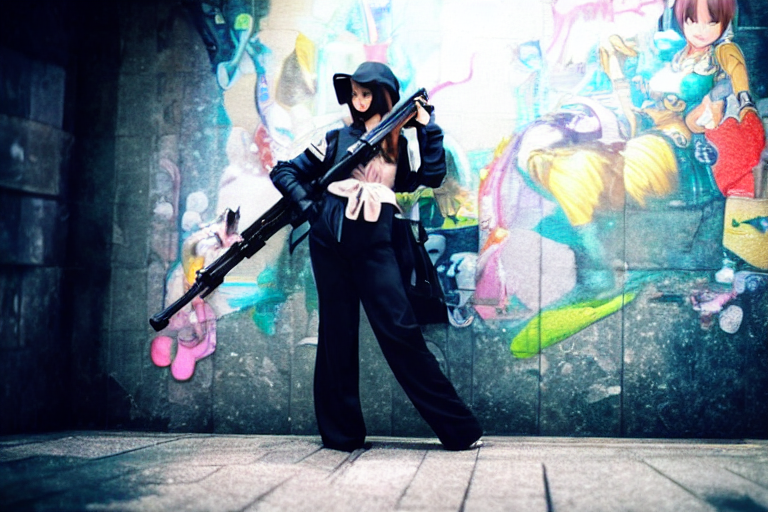

In [26]:
images[0][0]

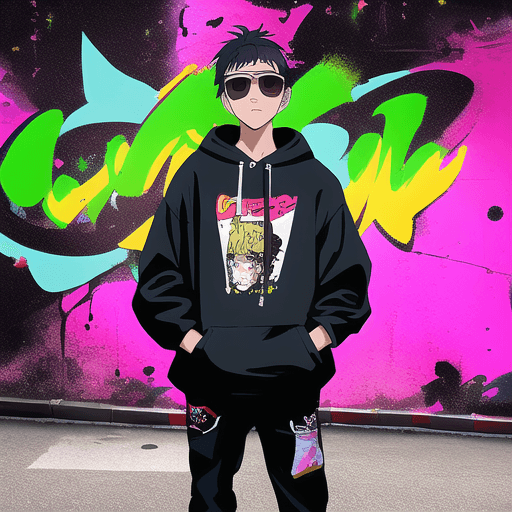

In [27]:
# https://opensea.io/assets/ethereum/0x495f947276749ce646f68ac8c248420045cb7b5e/1673696975965811788952744051363138032233820124664356965554422464093987274753
url = "https://i.seadn.io/gae/R600jlEWMtISS8Rsw6-cAWEBQVq-xR_DVYB5ZWmjLZ-JtCnvzn5GQBWhSko5NofLVoyypk4Mjtagj_XVxsDRMnEM8DLAq2pUegmY?auto=format&w=1920"


response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image

In [34]:
init_image = init_image.resize((768, 512))
prompt = "a rapper boy dancing"

with autocast("cuda"):
    images = pipe(prompt=prompt, init_image=init_image, strength=0.75, guidance_scale=7.5)

  0%|          | 0/38 [00:00<?, ?it/s]

In [35]:
images[0][0].save("nft_3.png")

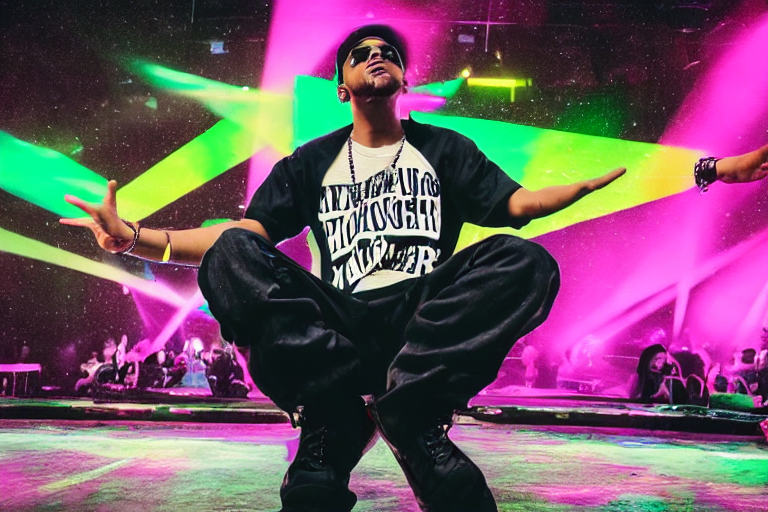

In [36]:
images[0][0]